# PA 4 - DATA WRANGLING AND DATA VISUALIZATION


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Import the ECE Board Exam 2 dataset
ECE = pd.read_excel('board2.xlsx')
ECE

,Name,Gender,Track,Hometown,Math,Electronics,GEAS,Communication
0,S1,Male,Instrumentation,Luzon,58,89,75,78
1,S2,Female,Communication,Mindanao,52,75,90,52
2,S3,Female,Instrumentation,Mindanao,83,74,77,57
3,S4,Male,Instrumentation,Visayas,65,58,91,68
4,S5,Male,Communication,Luzon,59,86,43,88
5,S6,Female,Microelectronics,Visayas,88,45,86,83
6,S7,Female,Instrumentation,Luzon,66,60,60,48
7,S8,Male,Instrumentation,Luzon,49,81,64,53
8,S9,Male,Instrumentation,Luzon,50,36,63,42
9,S10,Male,Microelectronics,Mindanao,80,84,61,44


In [4]:
# Calculate Average from the four recorded subject scores
subjects = ['Math', 'GEAS', 'Electronics', 'Communication']
ECE['Average'] = ECE[subjects].mean(axis=1)
ECE

,Name,Gender,Track,Hometown,Math,Electronics,GEAS,Communication,Average
0,S1,Male,Instrumentation,Luzon,58,89,75,78,75.00
1,S2,Female,Communication,Mindanao,52,75,90,52,67.25
2,S3,Female,Instrumentation,Mindanao,83,74,77,57,72.75
3,S4,Male,Instrumentation,Visayas,65,58,91,68,70.50
4,S5,Male,Communication,Luzon,59,86,43,88,69.00
5,S6,Female,Microelectronics,Visayas,88,45,86,83,75.50
6,S7,Female,Instrumentation,Luzon,66,60,60,48,58.50
7,S8,Male,Instrumentation,Luzon,49,81,64,53,61.75
8,S9,Male,Instrumentation,Luzon,50,36,63,42,47.75
9,S10,Male,Microelectronics,Mindanao,80,84,61,44,67.25


## A. VISAYAS COMMUNICATION DATAFRAME

In [5]:
# Filter students whose Hometown is Visayas and whose Track is Communication
VisComm = ECE.loc[
    (ECE['Hometown'] == 'Visayas')&
    (ECE['Track'] == 'Communication'),
    ['Name', 'Gender', 'Math', 'Electronics', 'Average']
]
VisComm

,Name,Gender,Math,Electronics,Average
10,S11,Female,48,56,54.75
11,S12,Male,89,67,76.00
17,S18,Male,81,40,63.50
21,S22,Female,64,39,62.50
27,S28,Male,85,53,67.75


In [6]:
# Display the number of rows in VisComm
len(VisComm)

5

## B. VISAYAS FEMALE DATAFRAME

In [7]:
# Filter students whose Hometown is Visayas and whose Gender is Female
VisFemale = ECE.loc[
    (ECE['Hometown'] == 'Visayas')& 
    (ECE['Gender'] == 'Female'),
    ['Name', 'Track', 'GEAS', 'Electronics', 'Average']]

VisFemale

,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
10,S11,Communication,48,56,54.75
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
23,S24,Microelectronics,60,45,57.75
25,S26,Instrumentation,83,47,65.75


In [8]:
# Display only VisFemale rows whose Average is at least 60
VisFemale.loc[VisFemale['Average'] >= 60]

,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
25,S26,Instrumentation,83,47,65.75


## C. CATEGORY-AVERAGE VISUALIZATION

In [9]:
# Compute the mean Average for each Track
taverage = ECE.groupby('Track')['Average'].mean()
taverage

Track
Communication       67.975
Instrumentation     65.225
Microelectronics    67.500
Name: Average, dtype: float64

In [10]:
# Compute the mean Average for each Gender
gaverage = ECE.groupby('Gender')['Average'].mean()
gaverage

Gender
Female    66.616667
Male      67.183333
Name: Average, dtype: float64

In [11]:
# Compute the mean Average for each Hometown
haverage = ECE.groupby('Hometown')['Average'].mean()
haverage

Hometown
Luzon       68.083333
Mindanao    66.678571
Visayas     65.750000
Name: Average, dtype: float64

### Bar Charts

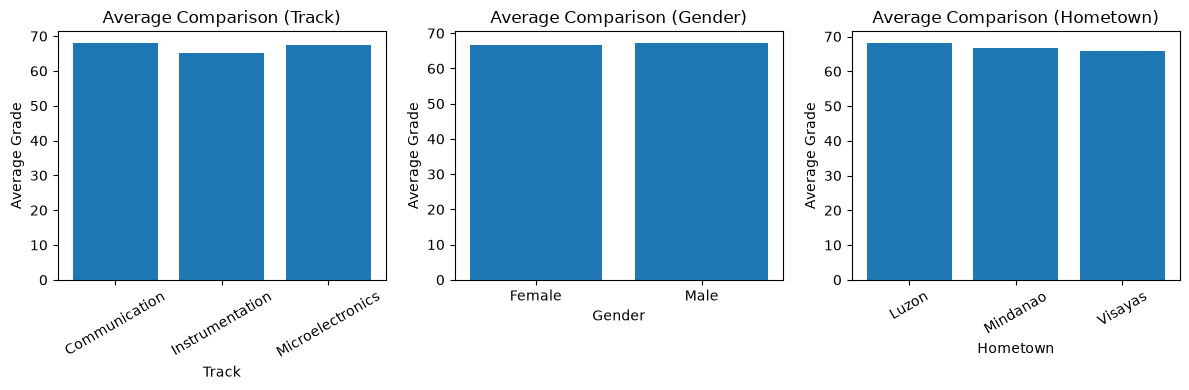

In [12]:
# Create one figure containing three bar charts
plt.figure(figsize=(12, 4))

# Average Comparison by Track
plt.subplot(1, 3, 1)
plt.bar(taverage.index, taverage.values)
plt.title('Average Comparison (Track)')
plt.xlabel('Track')
plt.ylabel('Average Grade')
plt.xticks(rotation=30)

# Average Comparison by Gender
plt.subplot(1, 3, 2)
plt.bar(gaverage.index, gaverage.values)
plt.title('Average Comparison (Gender)')
plt.xlabel('Gender')
plt.ylabel('Average Grade')

# Average Comparison by Hometown
plt.subplot(1, 3, 3)
plt.bar(haverage.index, havg if False else haverage.values)
plt.title('Average Comparison (Hometown)')
plt.xlabel('Hometown')
plt.ylabel('Average Grade')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [13]:
# Identify the category with the highest sample mean for each feature
highest_track = taverage.idxmax()
highest_gender = gaverage.idxmax()
highest_hometown = haverage.idxmax()

print(f"Track: {highest_track} has the highest sample mean Average of {taverage.max():.2f}.")
print(f"Gender: {highest_gender} has the highest sample mean Average of {gaverage.max():.2f}.")
print(f"Hometown: {highest_hometown} has the highest sample mean Average of {haverage.max():.2f}.")

Track: Communication has the highest sample mean Average of 67.97.
Gender: Male has the highest sample mean Average of 67.18.
Hometown: Luzon has the highest sample mean Average of 68.08.
